# 🥊 ML-AI Motion Controller - Level 4 Temporal Training

**Version 3.0** - Transformer-based Sequence Modeling (108 features x 10 frames)

---

In [16]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup Path
sys.path.insert(0, os.path.abspath("."))
import src.config as config
from src.data.processing import transform_dataset, create_sequences
from src.data.augmentation import augment_dataset
from src.model.temporal_model import PoseTransformerWrapper

print("✓ Libraries loaded (Level 4 Temporal)")

✓ Libraries loaded (Level 4 Temporal)


## 1. Configuration

In [17]:
WINDOW_SIZE = 10
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001

print(f"Window Size: {WINDOW_SIZE}")
print(f"Models Dir: {config.MODELS_DIR}")

Window Size: 10
Models Dir: d:\ML-AI Motion Controller\models


## 2. Data Loading & Sequence Creation

In [18]:
data_dir = os.path.join(config.DATASET_DIR, "by_class")
dfs = []

if os.path.exists(data_dir):
    csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
    for file in csv_files:
        file_path = os.path.join(data_dir, file)
        df_raw = pd.read_csv(file_path).dropna()
        # Apply 108-feature transformation
        df_pro = transform_dataset(df_raw)
        dfs.append(df_pro)
        print(f"✓ Loaded {file}: {len(df_pro)} samples")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Total raw samples: {len(df_all)}")

# Create Sequences (Sliding Window)
print("Generating temporal sequences...")
X_seq, y_seq = create_sequences(df_all, window_size=WINDOW_SIZE)
print(f"Sequence shape: {X_seq.shape}") # Expected (N, 10, 108)
print(f"Labels shape: {y_seq.shape}")

✓ Loaded block.csv: 500 samples
✓ Loaded dodge_back.csv: 300 samples
✓ Loaded dodge_front.csv: 300 samples
✓ Loaded dodge_left.csv: 300 samples
✓ Loaded dodge_right.csv: 300 samples
✓ Loaded final_skill.csv: 300 samples
✓ Loaded left_punch.csv: 300 samples
✓ Loaded neutral.csv: 500 samples
✓ Loaded right_punch.csv: 300 samples

📊 Total raw samples: 3100
Generating temporal sequences...
Sequence shape: (3019, 10, 108)
Labels shape: (3019,)


## 3. Data Splitting & Encoding

In [19]:
# We encode labels before splitting to ensure consistency
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_seq)

# Note: X_seq contains pose landmarks which are already relative/normalized in transform_dataset
# But we can apply a global scaler if needed. For Transformers, raw relative coords are often fine.

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train sequences: {len(X_train)}")
print(f"Test sequences: {len(X_test)}")
print(f"Classes: {encoder.classes_}")

Train sequences: 2415
Test sequences: 604
Classes: ['block' 'dodge_back' 'dodge_front' 'dodge_left' 'dodge_right'
 'final_skill' 'left_punch' 'neutral' 'right_punch']


## 4. Model Training (Transformer)

In [20]:
best_model = PoseTransformerWrapper(
    input_dim=108, 
    num_classes=len(encoder.classes_), 
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR
)

print("🚀 Starting PoseTransformer training...")
best_model.fit(X_train, y_train)
print("✅ Training complete.")

🚀 Starting PoseTransformer training...
✅ Training complete.


## 5. Evaluation

🏆 Test Accuracy: 98.68%

Classification Report:
              precision    recall  f1-score   support

       block       0.99      1.00      0.99        99
  dodge_back       1.00      0.93      0.96        58
 dodge_front       1.00      0.97      0.98        58
  dodge_left       0.95      1.00      0.97        58
 dodge_right       1.00      1.00      1.00        58
 final_skill       1.00      1.00      1.00        58
  left_punch       0.97      1.00      0.98        58
     neutral       0.98      0.99      0.98        99
 right_punch       1.00      0.98      0.99        58

    accuracy                           0.99       604
   macro avg       0.99      0.99      0.99       604
weighted avg       0.99      0.99      0.99       604



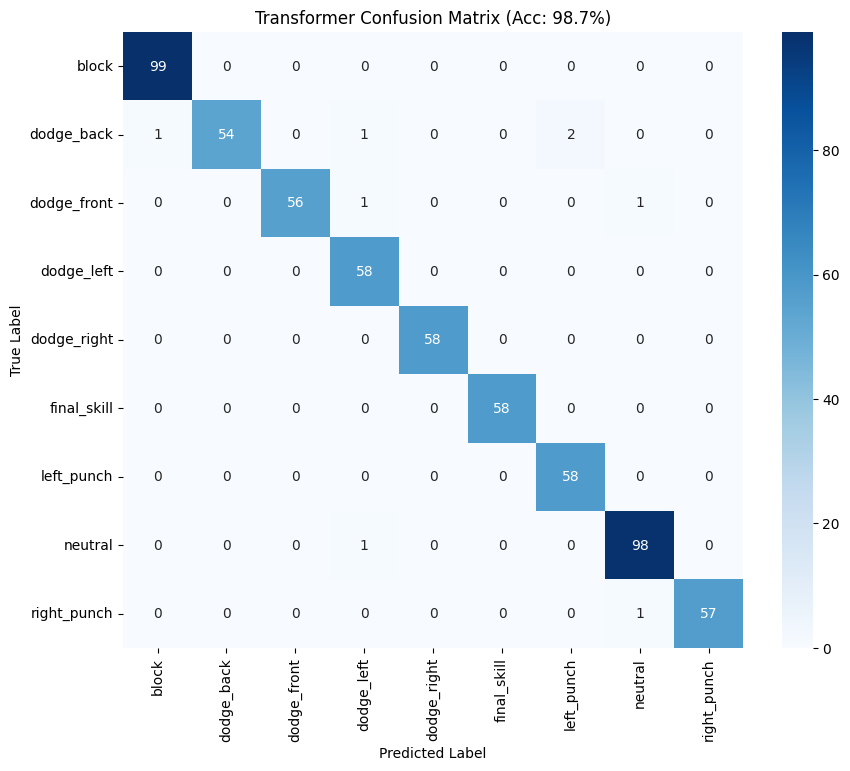

In [21]:
y_pred_encoded = best_model.predict(X_test)
# best_model.predict returns decoded labels if it was fitted with strings, 
# but here we fitted with y_encoded (numeric). So y_pred_encoded is numeric.
y_pred = encoder.inverse_transform(y_pred_encoded)
y_true = encoder.inverse_transform(y_test)

test_acc = accuracy_score(y_true, y_pred)
print(f"🏆 Test Accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred, labels=encoder.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap="Blues")
plt.title(f"Transformer Confusion Matrix (Acc: {test_acc*100:.1f}%)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

## 6. Save Model Artifacts

In [22]:
config.ensure_directories()

# Save the model (Wrapper includes the PyTorch model and weights)
with open(config.MODEL_FILE, "wb") as f:
    pickle.dump(best_model, f)

with open(config.ENCODER_FILE, "wb") as f:
    pickle.dump(encoder, f)

print(f"✅ Model saved to: {config.MODEL_FILE}")
print(f"✅ Encoder saved to: {config.ENCODER_FILE}")
print("\nReady for real-time inference!")

✓ Directories ready: d:\ML-AI Motion Controller\dataset, d:\ML-AI Motion Controller\models
✅ Model saved to: d:\ML-AI Motion Controller\models\boxing_model.pkl
✅ Encoder saved to: d:\ML-AI Motion Controller\models\label_encoder.pkl

Ready for real-time inference!
